In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
np.random.seed(42)
X = np.sort(np.random.rand(100, 1) * 10, axis=0)  # 100 points, 0 to 10
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])  # true curve + noise


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
degrees = [1, 2, 4, 8, 15]
train_errors = []
test_errors = []


In [5]:
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))


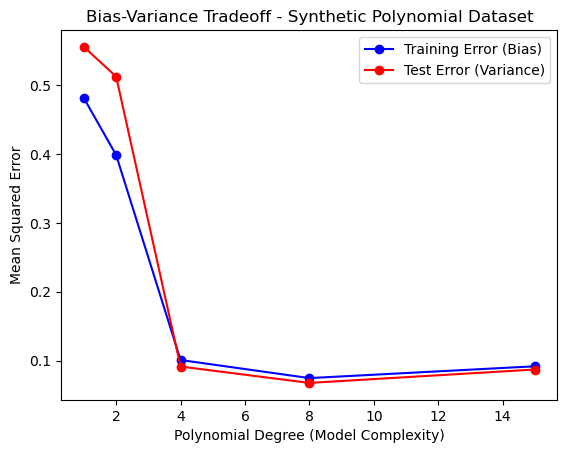

In [6]:
plt.plot(degrees, train_errors, marker='o', label="Training Error (Bias)", color="blue")
plt.plot(degrees, test_errors, marker='o', label="Test Error (Variance)", color="red")
plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff - Synthetic Polynomial Dataset")
plt.legend()
plt.show()